# Interview Request Analysis

In [40]:

# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns

In [41]:
# import dataset

df = pd.read_csv('Request_for_Interview.csv')

In [42]:
#display your dataframe

df.head(3)

,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter
0,Ali,22,M,15000,Highschool,Samsung Galaxy S3,True,True,True,True,False,False,False
1,Mutu,25,M,30000,Diploma,HTC One Note,True,True,True,False,False,False,False
2,Lim,33,M,36000,Diploma,iPhone 5,True,True,True,False,True,False,False


In [43]:
#get some info about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           20 non-null     object
 1   Age            20 non-null     int64 
 2   Gender         20 non-null     object
 3   Annual Income  20 non-null     int64 
 4   Education      20 non-null     object
 5   Phone Owned    20 non-null     object
 6   Email          20 non-null     bool  
 7   Web            20 non-null     bool  
 8   Mobile         20 non-null     bool  
 9   Walk-in        20 non-null     bool  
 10  Video Call     20 non-null     bool  
 11  Phone Call     20 non-null     bool  
 12  Letter         20 non-null     bool  
dtypes: bool(7), int64(2), object(4)
memory usage: 1.2+ KB


In [44]:
# Get statistical summary about the dataset

df.describe()

,Age,Annual Income
count,20.000000,20.000000
mean,31.550000,38710.000000
std,10.644865,32212.745108
min,19.000000,12000.000000
25%,22.750000,16750.000000
50%,27.500000,27500.000000
75%,36.000000,42750.000000
max,54.000000,120000.000000


### 1.    What is the median age of subjects in the sample size above?

In [ ]:
median_age = df['Age'].median()
median_age

27.5

The median age is 27.5

### 2.	What is the average salary difference of a person with only a diploma vs one with a Master's degree?

In [ ]:
avg_salary = df.groupby('Education')['Annual Income'].mean()
avg_salary

Education
Degree        70000.000000
Diploma       36000.000000
Highschool    15000.000000
Masters       77500.000000
Primary       15533.333333
Name: Annual Income, dtype: float64

In [47]:
salary_difference = avg_salary['Masters'] - avg_salary['Diploma']
salary_difference

41500.0

A person with a Master’s degree earns, on average, RM41,500 more per year than someone with a Diploma. 

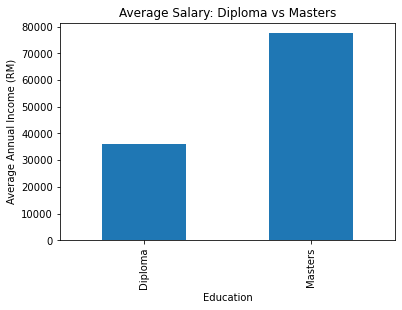

In [48]:
# plot a bar chart to show the difference of avg salary between diploma and masters

avg_salary.loc[['Diploma', 'Masters']].plot(kind='bar')
plt.ylabel("Average Annual Income (RM)")
plt.title("Average Salary: Diploma vs Masters")
plt.show()

### 3.	Does age affect the salary of someone with a diploma? Please justify in mathematical terms.

In [49]:
diploma_df = df[df['Education'] == 'Diploma']
diploma_df

,Name,Age,Gender,Annual Income,Education,Phone Owned,Email,Web,Mobile,Walk-in,Video Call,Phone Call,Letter
1,Mutu,25,M,30000,Diploma,HTC One Note,True,True,True,False,False,False,False
2,Lim,33,M,36000,Diploma,iPhone 5,True,True,True,False,True,False,False
3,Angie,47,F,45000,Diploma,iPhone 6s,True,False,False,True,True,True,True
11,Trevor,25,M,30000,Diploma,OnePlus 2,True,False,True,False,False,False,False
12,Melinda,39,F,33000,Diploma,Samsung Galaxy A8,True,False,False,False,False,False,False
13,Aishah,45,F,42000,Diploma,Lenovo VIBE Shot,True,False,False,False,False,False,False


In [50]:
# Calculate correlation between Age and Annual Income for Diploma holders

correlation = diploma_df['Age'].corr(diploma_df['Annual Income'])
correlation

0.9132066581121651

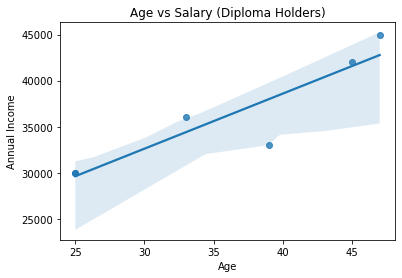

In [51]:
# plot a scatter plot with trendline to show the correlation

sns.regplot(
    x='Age',
    y='Annual Income',
    data=diploma_df
)
plt.title("Age vs Salary (Diploma Holders)")
plt.show()

The Pearson correlation coefficient between age and annual income for diploma holders is 0.913. This shows strong relationship between age and salary. This means that diploma holders tend to earn more as they get older. 

### 4.	How much do you think a diploma holder will be earning at the age of 40? Please share your hypothesis & the calculations that lead to that outcome.

In [52]:
coeff = np.polyfit(diploma_df['Age'], diploma_df['Annual Income'], 1)
coeff


array([  598.26589595, 14661.84971098])

In [53]:
predicted_salary_40 = coeff[0] * 40 + coeff[1]
predicted_salary_40

38592.485549132965

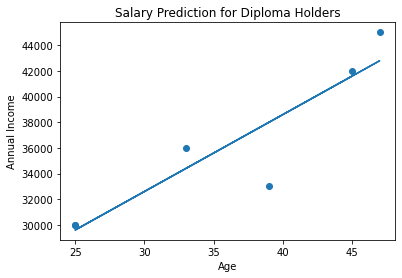

In [54]:
plt.scatter(diploma_df['Age'], diploma_df['Annual Income'])
plt.plot(
    diploma_df['Age'],
    coeff[0]*diploma_df['Age'] + coeff[1]
)
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.title("Salary Prediction for Diploma Holders")
plt.show()

Based on this regression model, the estimated annual income for a diploma holder at the age of 40 is approximately RM 38592.49.

### 5.	What kind of phone do you think someone who earns RM 5,000 & above per month will possess? Kindly advise on your assumptions, and the calculations you considered.

In [55]:
# find out the monthly income

df['Monthly Income'] = df['Annual Income'] / 12

In [56]:
# show the data of high income people

high_income = df[df['Monthly Income'] >= 5000]
high_income[['Name', 'Phone Owned', 'Monthly Income']]

,Name,Phone Owned,Monthly Income
6,Pierre,Nokia E63,10000.000000
7,Valerie,iPhone 3Gs,6666.666667
16,Wong,iPhone 6s+,9166.666667
17,Jill,iPhone 6s,6250.000000


The people who earn RM5,000 and above per month tend to use iPhones.

### 6.	What is the most preferred way of requesting an interview for someone who spends more than RM 2,000 for their phone?

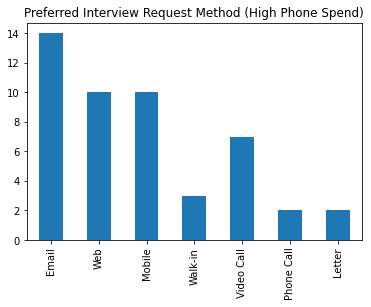

Most preferred method: Email
Highest sum: 14


In [67]:
# assume iphones & flagship Android phones > RM 2,000

expensive_phone_df = df[df['Phone Owned'].str.contains("iPhone|Galaxy|OnePlus|Xiaomi", na=False)]

# show the sum of each method
methods = ['Email','Web','Mobile','Walk-in','Video Call','Phone Call','Letter']
method_sums = expensive_phone_df[methods].sum()

# plot a bar chart to show the method with highest amount
method_sums.plot(kind='bar')
plt.title("Preferred Interview Request Method (High Phone Spend)")
plt.show()

# Find the highest sum
highest_sum = method_sums.max()

# Find which method has the highest sum
most_preferred_method = method_sums.idxmax()

# Display results
print("Most preferred method:", most_preferred_method)
print("Highest sum:", highest_sum)

For people who spend more than RM2,000 on their phones, the most preferred way of requesting an interview is Email, with a total of 14 people choosing this method. 